In [1]:
import copy
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
bathy = xr.open_dataset('/ocean/atall/MOAD/grid/bathymetry_202310b.nc')

In [3]:
iprob = 299-1
jprob = 429-1
delta = 2

[[ 9.1875  7.5     4.      4.      4.    ]
 [ 4.      4.      4.      4.      4.    ]
 [11.3125 11.625  13.     13.     13.    ]
 [13.25   13.125  13.     12.5    11.    ]
 [ 8.0625  7.875   7.1875  6.3125  7.125 ]]


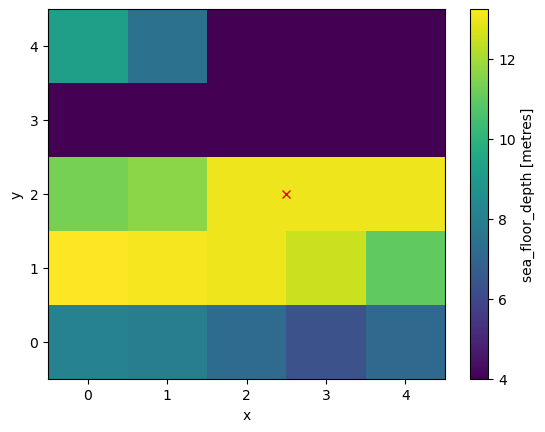

In [4]:
bathy.Bathymetry[jprob-delta:jprob+delta+1, iprob-delta:iprob+delta+1].plot()
plt.plot(delta+0.5, delta, 'rx');
print (bathy.Bathymetry[jprob+delta:jprob-delta-1:-1, iprob-delta:iprob+delta+1].values)

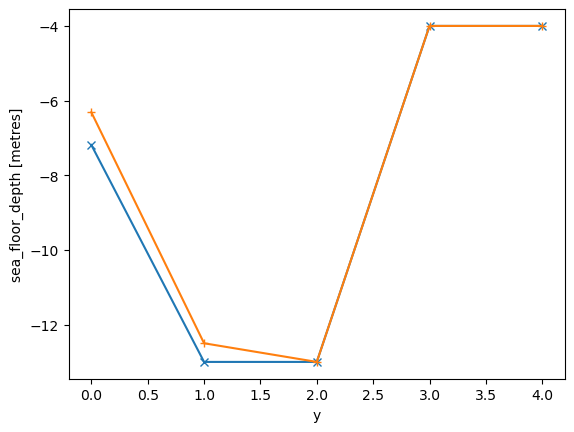

In [5]:
(-bathy.Bathymetry[jprob-delta:jprob+delta+1, iprob]).plot(marker='x');
(-bathy.Bathymetry[jprob-delta:jprob+delta+1, iprob+1]).plot(marker='+');

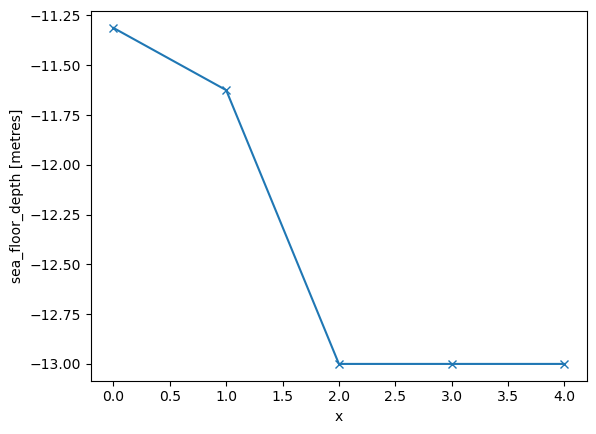

In [6]:
(-bathy.Bathymetry[jprob, iprob-delta:iprob+delta+1]).plot(marker='x');

In [7]:
new_bathy = copy.copy(bathy)

In [8]:
print (new_bathy.Bathymetry[jprob+delta:jprob-delta-1:-1, iprob-delta:iprob+delta+1].values)

[[ 9.1875  7.5     4.      4.      4.    ]
 [ 4.      4.      4.      4.      4.    ]
 [11.3125 11.625  13.     13.     13.    ]
 [13.25   13.125  13.     12.5    11.    ]
 [ 8.0625  7.875   7.1875  6.3125  7.125 ]]


In [9]:
print (new_bathy.Bathymetry[jprob, iprob-1].values)

11.625


In [10]:
new_bathy.Bathymetry[jprob, iprob-1] = 12.5

In [11]:
print (new_bathy.Bathymetry[jprob, iprob-1].values)

12.5


[[ 9.1875  7.5     4.      4.      4.    ]
 [ 4.      4.      4.      4.      4.    ]
 [11.3125 12.5    13.     13.     13.    ]
 [13.25   13.125  13.     12.5    11.    ]
 [ 8.0625  7.875   7.1875  6.3125  7.125 ]]


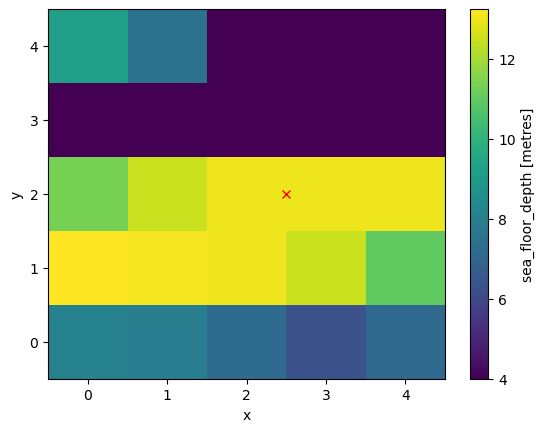

In [12]:
new_bathy.Bathymetry[jprob-delta:jprob+delta+1, iprob-delta:iprob+delta+1].plot()
plt.plot(delta+0.5, delta, 'rx');
print (new_bathy.Bathymetry[jprob+delta:jprob-delta-1:-1, iprob-delta:iprob+delta+1].values)

In [13]:
new_bathy.attrs

{'Conventions': 'CF-1.6',
 'title': 'Bathymetry 202310b',
 'institution': 'Dept of Earth, Ocean & Atmospheric Sciences, University of British Columbia',
 'source': '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry-deepen-SI-Sill.ipynb',
 'references': '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry_202310b.nc',
 'history': '[2023-10-31 14:27:35] Created netCDF4 zlib=True dataset.',
 'comment': 'Bathymetry processed 202310 Bathymetry. Deepen the deep of Victoria Sill'}

In [14]:
new_bathy.attrs['history'] = new_bathy.attrs['history'] + '[2024-12-04] Shallow one point of 202310b for stability'

In [15]:
new_bathy.attrs['title'] = 'Bathymetry 202412'

In [16]:
new_bathy.attrs

{'Conventions': 'CF-1.6',
 'title': 'Bathymetry 202412',
 'institution': 'Dept of Earth, Ocean & Atmospheric Sciences, University of British Columbia',
 'source': '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry-deepen-SI-Sill.ipynb',
 'references': '/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/bathymetry_202310b.nc',
 'history': '[2023-10-31 14:27:35] Created netCDF4 zlib=True dataset.[2024-12-04] Shallow one point of 202310b for stability',
 'comment': 'Bathymetry processed 202310 Bathymetry. Deepen the deep of Victoria Sill'}

In [17]:
new_bathy.to_netcdf('/ocean/atall/MOAD/grid/bathymetry_202412.nc')